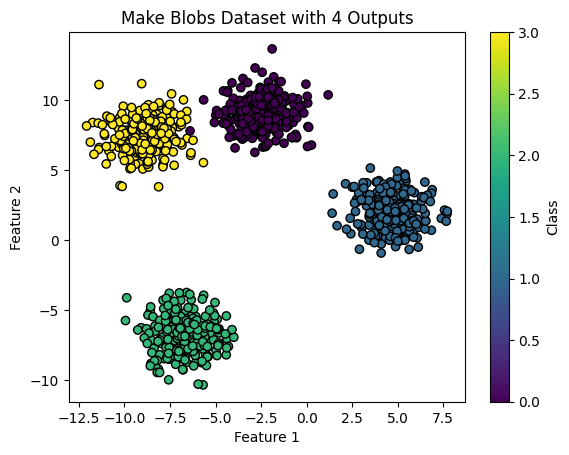

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import torch
from torch import nn
import numpy as np

# Create dataset with 4 clusters/classes
X, y = make_blobs(
    n_samples=1000,
    centers=4,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

# Scatter plot
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k")

plt.title("Make Blobs Dataset with 4 Outputs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Class")
plt.show()


## Model using k-nearest classifier 🆑

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        53
           3       1.00      1.00      1.00        57

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Predicted class for new point: 1


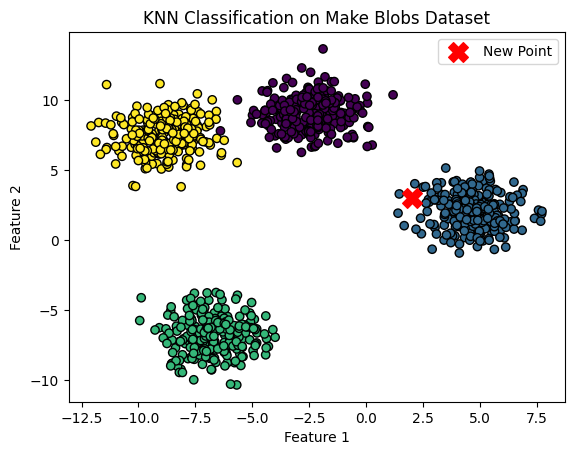

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create dataset with 4 output classes
X, y = make_blobs(
    n_samples=1000,
    centers=4,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create classification model
model = KNeighborsClassifier(n_neighbors=5)

# Train model
model.fit(X_train, y_train)

# Predict outputs
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

# Predict one new point
new_point = [[2, 3]]
prediction = model.predict(new_point)
print("Predicted class for new point:", prediction[0])

# Plot dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k")
plt.scatter(new_point[0][0], new_point[0][1], c="red", s=200, marker="X", label="New Point")

plt.title("KNN Classification on Make Blobs Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


## Using NN

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        53
           3       1.00      1.00      1.00        57

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Predicted class for new point: 1


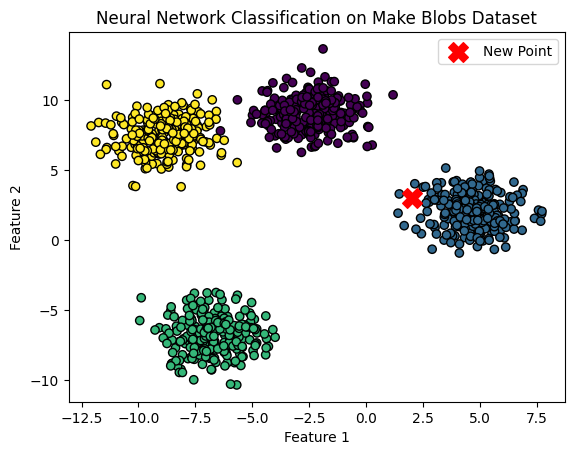

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Create dataset with 4 output classes
X, y = make_blobs(
    n_samples=1000,
    centers=4,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale data for better neural network training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Neural Network model
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

# Train model
model.fit(X_train_scaled, y_train)

# Predict outputs
y_pred = model.predict(X_test_scaled)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

# Predict a new point
new_point = [[2, 3]]
new_point_scaled = scaler.transform(new_point)
prediction = model.predict(new_point_scaled)

print("Predicted class for new point:", prediction[0])

# Plot original dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k")
plt.scatter(new_point[0][0], new_point[0][1], c="red", s=200, marker="X", label="New Point")

plt.title("Neural Network Classification on Make Blobs Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


## Torch NN


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_blobs(
    n_samples=1000,
    centers=4,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [17]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4)  # 4 classes
        )

    def forward(self, x):
        return self.model(x)

model = MLP()

In [18]:
criterion = nn.CrossEntropyLoss()  # for classification
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [19]:
for epoch in range(200):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.3577
Epoch 20, Loss: 0.5562
Epoch 40, Loss: 0.0881
Epoch 60, Loss: 0.0141
Epoch 80, Loss: 0.0091
Epoch 100, Loss: 0.0076
Epoch 120, Loss: 0.0068
Epoch 140, Loss: 0.0063
Epoch 160, Loss: 0.0060
Epoch 180, Loss: 0.0057


In [20]:
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

accuracy = (predicted == y_test).float().mean()
print("Accuracy:", accuracy.item())

Accuracy: 1.0


In [24]:
new_point = torch.tensor([[20, 3000]], dtype=torch.float32)
new_point = torch.tensor(scaler.transform(new_point), dtype=torch.float32)

with torch.no_grad():
    output = model(new_point)
    _, pred = torch.max(output, 1)

print("Predicted class:", pred.item())

Predicted class: 0
